# 1. Описание задачи

## Бизнес-контекст

Разрабатывается мобильный мессенджер с функцией умных подсказок. Во время набора сообщения приложение должно предлагать пользователю наиболее вероятное следующее слово.

Примеры работы функции:

| Введённый текст | Возможное следующее слово |
|---|---|
| `the president of the` | `united` |
| `i want to` | `go` |
| `the weather today is` | `sunny` |
| `new york is a` | `city` |

Такая функция применяется в мобильных клавиатурах, мессенджерах, поисковых строках и голосовых помощниках.

## Цель проекта

Цель проекта — обучить и сравнить несколько архитектур нейронных сетей для предсказания следующего слова, а затем определить, какая из них лучше подходит для использования на мобильном устройстве.

При выборе модели необходимо учитывать:

- качество предсказаний;
- количество параметров;
- размер модели;
- скорость обучения;
- скорость получения предсказания.

## Постановка задачи

Модель получает последовательность токенов и должна предсказать следующий токен.

Например:

```text
Вход:    the cat sat on the
Таргет:  cat sat on the mat

Таким образом, задача предсказания следующего слова рассматривается как задача многоклассовой классификации. Модель рассчитывает вероятности всех слов из словаря, а правильным классом является фактическое следующее слово.

In [1]:
%pip install -v numpy pandas matplotlib seaborn tqdm datasets transformers

Using pip 26.2.1 from d:\МИФИ_учеба\3_семестр\02_Работа_с_изображениями_и_текстами\01_проект\.venv\Lib\site-packages\pip (python 3.14)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# %pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu132

In [3]:
# %pip install "fsspec[http]==2026.6.0"

In [ ]:
import sys
import math
import time
import random
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM

d:\МИФИ_учеба\3_семестр\02_Работа_с_изображениями_и_текстами\01_проект\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
SEED = 42


def set_seed(seed: int = 42) -> None:
    """Фиксирует генераторы случайных чисел."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# True — быстрый локальный запуск
# False — итоговый запуск на полном датасете
FAST_RUN = True

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {DEVICE}")
print(f"Быстрый режим: {FAST_RUN}")

if torch.cuda.is_available():
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")

Python: 3.14.3
PyTorch: 2.14.1+cu132
Устройство: cuda
Быстрый режим: True
Видеокарта: NVIDIA GeForce RTX 5060 Ti


# 2. Загрузка WikiText-2

Для обучения и оценки моделей используется датасет **WikiText-2** — набор англоязычных текстов из статей Википедии.

Датасет имеет стандартное разделение:

- `train` — обучение моделей;
- `validation` — оценка качества после каждой эпохи;
- `test` — итоговая проверка лучших моделей.

На этом этапе загрузим данные, проверим их структуру и выведем несколько примеров. Обучающая, валидационная и тестовая части не будут смешиваться.

In [10]:
DATASET_NAME ="Salesforce/wikitext"
DATASET_CONFIG = "wikitext-2-raw-v1"

dataset = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG
)

dataset

Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 891345.90 examples/s]


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

# 3. Анализ данных

Проведём разведочный анализ WikiText-2. Определим количество пустых и непустых текстовых блоков, приблизительное число слов и распределение длин текстов.

Это позволит оценить объём данных и выбрать подходящие параметры для формирования обучающих последовательностей.

In [11]:
required_splits = {"train", "validation", "test"}

assert required_splits.issubset(dataset.keys()), (
    "В датасете отсутствует один из обязательных разделов"
)

for split_name in ["train", "validation", "test"]:
    split = dataset[split_name]

    print(f"{split_name}:")
    print(f"  количество строк: {len(split):,}")
    print(f"  столбцы: {split.column_names}")

train:
  количество строк: 36,718
  столбцы: ['text']
validation:
  количество строк: 3,760
  столбцы: ['text']
test:
  количество строк: 4,358
  столбцы: ['text']


In [12]:
split_sizes = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [
            len(dataset["train"]),
            len(dataset["validation"]),
            len(dataset["test"]),
        ],
    }
)

split_sizes

,split,rows
0,train,36718
1,validation,3760
2,test,4358


Датасет успешно загружен и содержит три обязательные части:

- обучающая выборка - 36 718 строк;
- валидационная выборка - 3 760 строк;
- тестовая выборка - 4 358 строк.

Каждая часть содержит один столбец `text` с текстовыми блоками. Обучающая выборка является самой большой, поскольку используется для настройки параметров моделей. Валидационная выборка будет применяться для контроля качества во время обучения, а тестовая — для окончательной оценки лучших моделей.

Количество строк не соответствует количеству слов или предложений: одна строка может быть заголовком, абзацем либо быть пустой. Поэтому фактический объём текстовых данных будет определён на этапе разведочного анализа.

In [13]:
def show_text_examples(split, number_of_examples=5):
    """Выводит несколько непустых текстов из выбранной части датасета."""
    
    shown = 0

    for row in split:
        text = row["text"].strip()

        if not text:
            continue

        shown += 1
        print(f"Пример {shown}:")
        print(text[:500])
        print("-" * 80)

        if shown == number_of_examples:
            break


show_text_examples(
    dataset["train"],
    number_of_examples=5
)

Пример 1:
= Valkyria Chronicles III =
--------------------------------------------------------------------------------
Пример 2:
Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and fo
--------------------------------------------------------------------------------
Пример 3:
The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more forgiving for series newcomers . Characte

### Вывод по примерам текстов

В WikiText-2 представлены не только обычные текстовые абзацы, но и заголовки статей и разделов, отмеченные символами `=`. Строки датасета не всегда соответствуют отдельным предложениям.

В текстах сохраняются регистр, пунктуация, числа, имена собственные и неанглийские символы. Пустые строки необходимо исключить перед формированием последовательностей.

Перед обучением потребуется выполнить минимальную предобработку:

- удалить пустые строки;
- обработать служебные символы заголовков;
- определить правила токенизации слов и знаков препинания;
- добавить специальный токен конца текстового блока.

Сильную очистку текста проводить не следует, поскольку пунктуация и структура текста содержат полезную информацию для предсказания следующего слова.

In [16]:
dataset_statistics = []

for split_name in ["train", "validation", "test"]:
    texts = dataset[split_name]["text"]

    non_empty_texts = [
        text for text in texts
        if text.strip()
    ]

    number_of_words = sum(
        len(text.split())
        for text in non_empty_texts
    )

    number_of_characters = sum(
        len(text)
        for text in non_empty_texts
    )

    dataset_statistics.append(
        {
            "split": split_name,
            "all_rows": len(texts),
            "non_empty_rows": len(non_empty_texts),
            "empty_rows": len(texts) - len(non_empty_texts),
            "approximate_words": number_of_words,
            "characters": number_of_characters,
        }
    )

statistics_df = pd.DataFrame(dataset_statistics)

statistics_df["empty_percent"] = (
    statistics_df["empty_rows"]
    / statistics_df["all_rows"]
    * 100
).round(2)

statistics_df["average_words_per_text"] = (
    statistics_df["approximate_words"]
    / statistics_df["non_empty_rows"]
).round(2)

statistics_df

,split,all_rows,non_empty_rows,empty_rows,approximate_words,characters,empty_percent,average_words_per_text
0,train,36718,23767,12951,2051910,10892990,35.27,86.33
1,validation,3760,2461,1299,213886,1142150,34.55,86.91
2,test,4358,2891,1467,241211,1285622,33.66,83.44


### Вывод по объёму данных

Обучающая выборка содержит 36 718 строк, из которых 23 767 являются непустыми. Приблизительный объём обучающего текста составляет 2,05 млн слов и 10,9 млн символов.

Во всех частях датасета доля пустых строк составляет около 34–35%. Такие строки не содержат полезной информации, поэтому перед токенизацией они будут исключены.

Средняя длина непустого текстового блока составляет:

- 86,33 слова в обучающей выборке;
- 86,91 слова в валидационной выборке;
- 83,44 слова в тестовой выборке.

Средние значения близки во всех трёх частях, поэтому распределение текстов по длине выглядит согласованным. Обучающая выборка существенно больше валидационной и тестовой, что соответствует её назначению.

Количество слов пока является приблизительным, поскольку рассчитано простым разделением текста по пробелам. Точное количество токенов и размер словаря будут определены после реализации пословной токенизации.

### Подсчет количества слов

In [17]:
text_lengths = []

for split_name in ["train", "validation", "test"]:
    for text in dataset[split_name]["text"]:
        text = text.strip()

        if not text:
            continue

        text_lengths.append(
            {
                "split": split_name,
                "word_count": len(text.split()),
            }
        )

lengths_df = pd.DataFrame(text_lengths)

lengths_df.head()

,split,word_count
0,train,5
1,train,127
2,train,91
3,train,101
4,train,5


### Статистика размеров текстовых данных

In [18]:
length_statistics = (
    lengths_df
    .groupby("split")["word_count"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
    )
    .round(2)
)

percentiles = (
    lengths_df
    .groupby("split")["word_count"]
    .quantile([0.75, 0.90, 0.95, 0.99])
    .unstack()
    .rename(
        columns={
            0.75: "p75",
            0.90: "p90",
            0.95: "p95",
            0.99: "p99",
        }
    )
    .round(2)
)

length_statistics = length_statistics.join(percentiles)
length_statistics

,count,mean,median,minimum,maximum,p75,p90,p95,p99
split,,,,,,,,,
test,2891,83.44,67.0,1,481,131.0,198.0,234.5,322.4
train,23767,86.33,74.0,1,699,139.0,200.0,237.0,319.0
validation,2461,86.91,75.0,1,429,142.0,199.0,231.0,303.4


Длина текстов распределена похоже во всех выборках. Типичный блок содержит 67–75 слов, однако встречаются длинные абзацы до 699 слов. Разница между средним и медианой указывает на наличие длинных текстов-выбросов.


### Распределени длины текстовых блоков

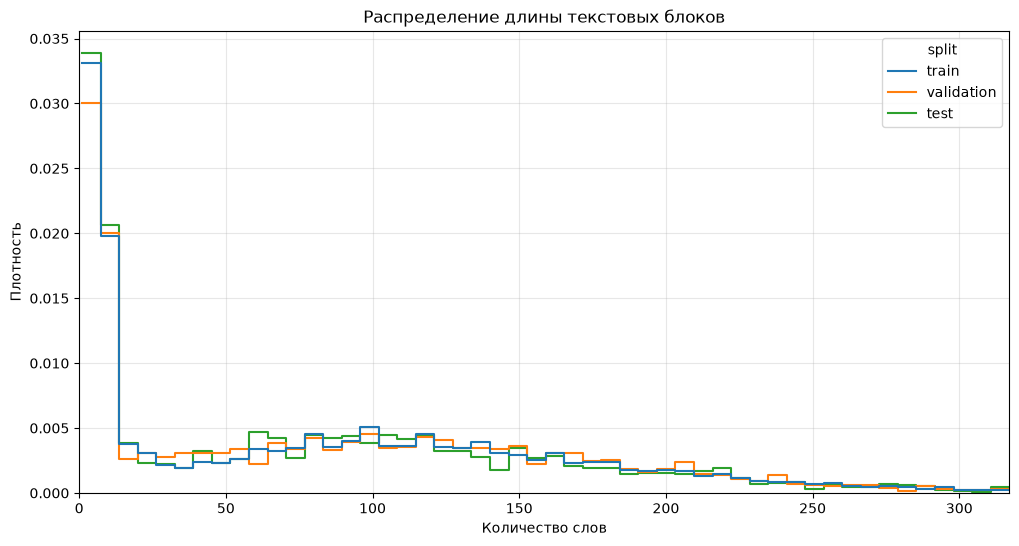

In [19]:
plot_limit = int(lengths_df["word_count"].quantile(0.99))

plt.figure(figsize=(12, 6))

sns.histplot(
    data=lengths_df[
        lengths_df["word_count"] <= plot_limit
    ],
    x="word_count",
    hue="split",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
)

plt.title("Распределение длины текстовых блоков")
plt.xlabel("Количество слов")
plt.ylabel("Плотность")
plt.xlim(0, plot_limit)
plt.grid(alpha=0.3)
plt.show()

Распределения во всех выборках почти совпадают. В данных много коротких блоков-заголовков и присутствует длинный хвост до 300 слов.

### Длина текстовых блоков

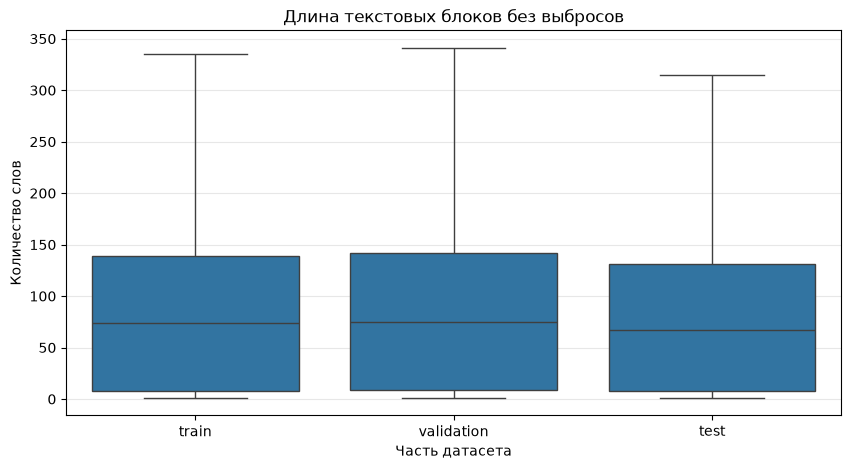

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=lengths_df,
    x="split",
    y="word_count",
    showfliers=False,
)

plt.title("Длина текстовых блоков без выбросов")
plt.xlabel("Часть датасета")
plt.ylabel("Количество слов")
plt.grid(axis="y", alpha=0.3)
plt.show()

Медианы и разброс длины текстов во всех частях датасета близки. Это означает, что `train`, `validation` и `test` имеют схожее распределение и подходят для корректного обучения и оценки моделей.

# 4. Предобработка данных

Перед очисткой проверим количество заголовков, предложений и специальных обозначений пунктуации. Это поможет определить необходимые правила предобработки текста.

In [ ]:


markup_statistics = []

for split_name in ["train", "validation", "test"]:
    texts = [
        text.strip()
        for text in dataset[split_name]["text"]
        if text.strip()
    ]

    headings = sum(
        text.startswith("=") and text.endswith("=")
        for text in texts
    )

    approximate_sentences = sum(
        len(re.findall(r"[.!?](?:\s|$)", text))
        for text in texts
    )

    full_text = " ".join(texts)

    markup_statistics.append(
        {
            "split": split_name,
            "headings": headings,
            "approximate_sentences": approximate_sentences,
            "hyphen_markers": full_text.count("@-@"),
            "comma_markers": full_text.count("@,@"),
            "period_markers": full_text.count("@.@"),
        }
    )

markup_df = pd.DataFrame(markup_statistics)
markup_df

,split,headings,approximate_sentences,hyphen_markers,comma_markers,period_markers
0,train,6211,78807,16906,2699,3194
1,validation,620,8439,1864,391,263
2,test,706,9410,2114,381,522


Во всех частях датасета встречается служебная разметка заголовков и специальные обозначения пунктуации. Перед токенизацией заменим `@-@`, `@,@` и `@.@` на обычные знаки, а из заголовков удалим символы `=`, сохранив их текст.

Количество предложений является приблизительным, поскольку рассчитано с помощью регулярного выражения. Распределение служебных элементов между выборками выглядит схожим.

In [23]:
markers = ["@-@", "@,@", "@.@"]

for marker in markers:
    examples = [
        text.strip()
        for text in dataset["train"]["text"]
        if marker in text
    ][:3]

    print(f"\nМаркер {marker!r}:")
    
    for example in examples:
        position = example.find(marker)
        start = max(0, position - 50)
        end = min(len(example), position + 50)

        print(example[start:end])


Маркер '@-@':
Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media
ames , Valkyria Chronicles III is a tactical role @-@ playing game where players take control of a m
g missions , players select each unit using a top @-@ down perspective of the battlefield map : once

Маркер '@,@':
es charts . By early February , the game sold 102 @,@ 779 units , coming in second overall to The La
t , supervised the construction . Originally $ 14 @,@ 000 was allocated for the construction of the 
 February 5 , six militia units , consisting of 1 @,@ 000 men , with a guarantee that the numbers co

Маркер '@.@':
ilding was designed with 3 @-@ foot @-@ thick ( 0 @.@ 91 m ) exterior walls . The original plans cal
orld Has Come was purchased by Queen Mary for ₤ 5 @.@ 5 @.@ 0 in 1926 . The Croydon Art Society hung
itats off northern Australia . Reaching 24 cm ( 9 @.@ 4 in ) in width , this species has a diamond @


Вывод

Просмотр примеров показал, что `@-@`, `@,@` и `@.@` обозначают дефис, запятую и точку внутри слов или чисел. Перед токенизацией заменим их на обычные символы без окружающих пробелов.

Создаём функцию очистки

In [26]:
def clean_text(text):
    """Очищает один текстовый блок WikiText-2."""

    text = text.strip()

    if not text:
        return ""

    # Восстанавливаем пунктуацию
    text = re.sub(r"\s*@-@\s*", "-", text)
    text = re.sub(r"\s*@,@\s*", ",", text)
    text = re.sub(r"\s*@\.@\s*", ".", text)

    # Убираем символы разметки заголовков по краям
    if text.startswith("=") and text.endswith("="):
        text = re.sub(r"^(?:=\s*)+", "", text)
        text = re.sub(r"(?:\s*=\s*)+$", "", text)

    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text

Проверяем функцию на примерах

In [27]:
example_texts = [
    text
    for text in dataset["train"]["text"]
    if text.strip()
][:5]

for original_text in example_texts:
    print("До:   ", original_text[:200])
    print("После:", clean_text(original_text)[:200])
    print("-" * 80)

До:     = Valkyria Chronicles III = 

После: Valkyria Chronicles III
--------------------------------------------------------------------------------
До:     Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p
После: Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role-playin
--------------------------------------------------------------------------------
До:     The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adju
После: The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the stan

Очищаем все выборки

In [28]:
raw_dataset = dataset

cleaned_dataset = raw_dataset.map(
    lambda row: {"text": clean_text(row["text"])}
)

cleaned_dataset = cleaned_dataset.filter(
    lambda row: bool(row["text"])
)

Filter: 100%|██████████| 3760/3760 [00:00<00:00, 454706.43 examples/s]


Проверяем результат

In [29]:
for split_name in ["train", "validation", "test"]:
    texts = cleaned_dataset[split_name]["text"]
    full_text = " ".join(texts)

    print(f"{split_name}:")
    print(f"  текстов: {len(texts):,}")
    print(f"  пустых: {sum(not text.strip() for text in texts)}")
    print(
        "  оставшихся маркеров:",
        sum(full_text.count(marker) for marker in ["@-@", "@,@", "@.@"]),
    )

train:
  текстов: 23,767
  пустых: 0
  оставшихся маркеров: 0
validation:
  текстов: 2,461
  пустых: 0
  оставшихся маркеров: 0
test:
  текстов: 2,891
  пустых: 0
  оставшихся маркеров: 0


# 5. Создание выборок для быстрого запуска

Для отладки создадим уменьшенные версии обучающей, валидационной и тестовой выборок. Они позволят быстро проверить токенизацию, формирование последовательностей и обучение моделей.

При итоговом запуске `FAST_RUN` будет установлен в `False`, и модели будут обучены на полном датасете.

In [30]:
from datasets import DatasetDict

FAST_LIMITS = {
    "train": 2000,
    "validation": 300,
    "test": 300,
}

if FAST_RUN:
    working_dataset = DatasetDict(
        {
            split_name: (
                cleaned_dataset[split_name]
                .shuffle(seed=SEED)
                .select(
                    range(
                        min(
                            FAST_LIMITS[split_name],
                            len(cleaned_dataset[split_name]),
                        )
                    )
                )
            )
            for split_name in ["train", "validation", "test"]
        }
    )
else:
    working_dataset = cleaned_dataset

In [31]:
for split_name in ["train", "validation", "test"]:
    print(
        f"{split_name}: "
        f"{len(working_dataset[split_name]):,} текстов"
    )

train: 2,000 текстов
validation: 300 текстов
test: 300 текстов


Уменьшенные выборки используются только для проверки работоспособности кода. Финальные значения метрик будут рассчитаны после обучения на полном датасете. Обе рекуррентные модели будут использовать одинаковые выборки.

# 6. Пословная токенизация

Преобразуем каждый текстовый блок в последовательность токенов. Слова будут приведены к нижнему регистру, что уменьшит размер словаря. Знаки препинания будут сохранены как отдельные токены, поскольку они также важны для языковой модели.

### 6.1 Функция токенизации

In [32]:
TOKEN_PATTERN = re.compile(
    r"\w+(?:['’]\w+)*|['’]\w+|[^\w\s]",
    flags=re.UNICODE,
)


def tokenize(text):
    """Разбивает текст на слова и знаки препинания."""

    text = text.lower()
    return TOKEN_PATTERN.findall(text)

Проверка на примере

In [33]:
example = "The player's role-playing game costs 1,000 dollars."

print("Исходный текст:")
print(example)

print("\nТокены:")
print(tokenize(example))

Исходный текст:
The player's role-playing game costs 1,000 dollars.

Токены:
['the', "player's", 'role', '-', 'playing', 'game', 'costs', '1', ',', '000', 'dollars', '.']


Проверка на WikiText-2

In [34]:
sample_text = working_dataset["train"][0]["text"]
sample_tokens = tokenize(sample_text)

print("Текст:")
print(sample_text[:500])

print("\nПервые 50 токенов:")
print(sample_tokens[:50])

print(f"\nКоличество токенов: {len(sample_tokens)}")

Текст:
The ship 's primary armament consisted of four 30.5 cm ( 12 in ) 45-caliber guns in two twin gun turrets . This was augmented by a heavy secondary battery of eight 24 cm ( 9.4 in ) guns in four wing turrets . The tertiary battery consisted of twenty 10 cm L / 50 guns in casemated single mounts , four 47 mm ( 1.85 in ) L / 44 and one 47 mm L / 33 quick-firing guns . Furthermore , the ship 's boats were equipped with two 66 mm ( 2.6 in ) landing guns for operations shore . Three 45 cm ( 17.7 in ) 

Первые 50 токенов:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in', 'two', 'twin', 'gun', 'turrets', '.', 'this', 'was', 'augmented', 'by', 'a', 'heavy', 'secondary', 'battery', 'of', 'eight', '24', 'cm', '(', '9', '.', '4', 'in', ')', 'guns', 'in', 'four', 'wing', 'turrets', '.']

Количество токенов: 140


Токенизатор приводит слова к нижнему регистру и отделяет пунктуацию. Это уменьшает размер словаря и позволяет модели предсказывать не только слова, но и знаки препинания.

### 6.2 Построение словаря

Словарь строится только по обучающей выборке, чтобы исключить утечку информации из `validation` и `test`.

Сначала подсчитаем частоты токенов и проверим несколько значений `min_freq`. Редкие токены будут заменяться на `<unk>`. Это уменьшит размер модели, поскольку размер выходного слоя напрямую зависит от количества токенов в словаре.

Подсчёт токенов

In [35]:
train_token_counts = Counter()

for text in tqdm(
    working_dataset["train"]["text"],
    desc="Подсчёт токенов",
):
    train_token_counts.update(tokenize(text))

total_train_tokens = sum(train_token_counts.values())
unique_train_tokens = len(train_token_counts)

print(f"Всего токенов: {total_train_tokens:,}")
print(f"Уникальных токенов: {unique_train_tokens:,}")

Подсчёт токенов: 100%|██████████| 2000/2000 [00:00<00:00, 11906.18it/s]

Всего токенов: 175,383
Уникальных токенов: 19,423


Самые частые токены

In [36]:
frequent_tokens_df = pd.DataFrame(
    train_token_counts.most_common(20),
    columns=["token", "frequency"],
)

frequent_tokens_df

,token,frequency
0,the,11307
1,",",8965
2,.,7355
3,of,4826
4,and,4322
5,in,3891
6,to,3373
7,a,3146
8,"""",2659
9,was,1792


Выбор min_freq

In [37]:
MIN_FREQ_CANDIDATES = [1, 2, 3, 5, 10]

vocabulary_statistics = []

for min_freq in MIN_FREQ_CANDIDATES:
    retained_tokens = {
        token
        for token, frequency in train_token_counts.items()
        if frequency >= min_freq
    }

    covered_occurrences = sum(
        frequency
        for token, frequency in train_token_counts.items()
        if frequency >= min_freq
    )

    vocabulary_statistics.append(
        {
            "min_freq": min_freq,
            "vocabulary_size": len(retained_tokens) + 2,
            "coverage_percent": (
                covered_occurrences / total_train_tokens * 100
            ),
            "unknown_percent": (
                100 - covered_occurrences / total_train_tokens * 100
            ),
        }
    )

vocabulary_statistics_df = pd.DataFrame(
    vocabulary_statistics
).round(3)

vocabulary_statistics_df

,min_freq,vocabulary_size,coverage_percent,unknown_percent
0,1,19425,100.000,0.000
1,2,9747,94.482,5.518
2,3,6767,91.084,8.916
3,5,4226,86.177,13.823
4,10,2097,78.267,21.733


#### Вывод

При `min_freq = 2` размер словаря уменьшается почти в два раза, а покрытие обучающего текста остаётся высоким — 94,5%. При более высоких порогах доля неизвестных токенов заметно увеличивается. Поэтому предварительно выбрано значение `min_freq = 2`.

Перед окончательным выбором проверим долю <unk> на validation и test:

In [38]:
MIN_FREQ = 2

known_tokens = {
    token
    for token, frequency in train_token_counts.items()
    if frequency >= MIN_FREQ
}

for split_name in ["validation", "test"]:
    split_tokens = [
        token
        for text in working_dataset[split_name]["text"]
        for token in tokenize(text)
    ]

    unknown_count = sum(
        token not in known_tokens
        for token in split_tokens
    )

    unknown_percent = unknown_count / len(split_tokens) * 100

    print(
        f"{split_name}: "
        f"{unknown_percent:.2f}% неизвестных токенов"
    )

validation: 11.83% неизвестных токенов
test: 11.91% неизвестных токенов


Доля неизвестных токенов на `validation` и `test` практически одинакова — около 12%, что говорит о схожести выборок. Высокое значение связано с использованием уменьшенной обучающей выборки в режиме `FAST_RUN`.

Для отладки оставим `min_freq = 2`. При итоговом запуске на полном `train` словарь и доля неизвестных токенов будут пересчитаны.

Следующий этап — окончательно построить словарь, присвоить токенам числовые индексы и закодировать весь текст.

### 6.3 Создание словаря

In [39]:
SPECIAL_TOKENS = ["<unk>", "<eos>"]

vocabulary_tokens = [
    token
    for token, frequency in sorted(
        train_token_counts.items(),
        key=lambda item: (-item[1], item[0]),
    )
    if frequency >= MIN_FREQ
]

id_to_token = SPECIAL_TOKENS + vocabulary_tokens

token_to_id = {
    token: token_id
    for token_id, token in enumerate(id_to_token)
}

UNK_ID = token_to_id["<unk>"]
EOS_ID = token_to_id["<eos>"]

VOCAB_SIZE = len(id_to_token)

print(f"Размер словаря: {VOCAB_SIZE:,}")
print(f"ID <unk>: {UNK_ID}")
print(f"ID <eos>: {EOS_ID}")

Размер словаря: 9,747
ID <unk>: 0
ID <eos>: 1


Кодирование и декодирование

In [40]:
def encode_text(text):
    """Преобразует текст в индексы и добавляет <eos>."""

    token_ids = [
        token_to_id.get(token, UNK_ID)
        for token in tokenize(text)
    ]

    return token_ids + [EOS_ID]


def decode_ids(token_ids):
    """Преобразует индексы обратно в токены."""

    return [
        id_to_token[token_id]
        for token_id in token_ids
    ]

Проверка

In [41]:
sample_text = working_dataset["train"][0]["text"]
sample_ids = encode_text(sample_text)

print("Исходный текст:")
print(sample_text[:300])

print("\nПервые индексы:")
print(sample_ids[:30])

print("\nОбратное преобразование:")
print(decode_ids(sample_ids[:30]))

Исходный текст:
The ship 's primary armament consisted of four 30.5 cm ( 12 in ) 45-caliber guns in two twin gun turrets . This was augmented by a heavy secondary battery of eight 24 cm ( 9.4 in ) guns in four wing turrets . The tertiary battery consisted of twenty 10 cm L / 50 guns in casemated single mounts , fou

Первые индексы:
[2, 620, 17, 1141, 2698, 1264, 5, 96, 293, 4, 110, 1037, 21, 273, 7, 22, 824, 12, 3135, 571, 7, 49, 2082, 478, 3011, 4, 34, 11, 0, 19]

Обратное преобразование:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in', 'two', 'twin', 'gun', 'turrets', '.', 'this', 'was', '<unk>', 'by']


Создание потоков токенов

In [42]:
encoded_splits = {}

for split_name in ["train", "validation", "test"]:
    token_stream = []

    for text in tqdm(
        working_dataset[split_name]["text"],
        desc=f"Кодирование {split_name}",
    ):
        token_stream.extend(encode_text(text))

    encoded_splits[split_name] = torch.tensor(
        token_stream,
        dtype=torch.long,
    )

    print(
        f"{split_name}: "
        f"{len(encoded_splits[split_name]):,} токенов"
    )

Кодирование train: 100%|██████████| 2000/2000 [00:00<00:00, 11517.94it/s]


train: 177,383 токенов


Кодирование validation: 100%|██████████| 300/300 [00:00<00:00, 11105.15it/s]


validation: 27,508 токенов


Кодирование test: 100%|██████████| 300/300 [00:00<00:00, 10609.90it/s]

test: 24,514 токенов


Словарь построен только по обучающей выборке. Редкие и неизвестные токены заменяются на `<unk>`, а после каждого текстового блока добавляется `<eos>`. Все части датасета преобразованы в числовые последовательности.

# 7. Dataset и DataLoader

Следующий этап - создать Dataset и DataLoader с правильным сдвигом входа и таргета.

### 7.1 Dataset для языковой модели

In [43]:
class LanguageModelDataset(Dataset):
    def __init__(self, token_stream, seq_len):
        self.token_stream = token_stream
        self.seq_len = seq_len

        self.number_of_sequences = (
            len(token_stream) - 1
        ) // seq_len

    def __len__(self):
        return self.number_of_sequences

    def __getitem__(self, index):
        start = index * self.seq_len
        end = start + self.seq_len + 1

        sequence = self.token_stream[start:end]

        x = sequence[:-1]
        y = sequence[1:]

        return x, y

Создание наборов данных

In [44]:
SEQ_LEN = 64
BATCH_SIZE = 64

sequence_datasets = {
    split_name: LanguageModelDataset(
        encoded_splits[split_name],
        seq_len=SEQ_LEN,
    )
    for split_name in ["train", "validation", "test"]
}

for split_name, split_dataset in sequence_datasets.items():
    print(
        f"{split_name}: "
        f"{len(split_dataset):,} последовательностей"
    )

train: 2,771 последовательностей
validation: 429 последовательностей
test: 383 последовательностей


Поверка сдвига. В результате Y должен быть сдвинут относительно X на один токен:

In [45]:
x_example, y_example = sequence_datasets["train"][0]

print("X:")
print(decode_ids(x_example[:20].tolist()))

print("\nY:")
print(decode_ids(y_example[:20].tolist()))

assert torch.equal(
    x_example[1:],
    y_example[:-1],
), "X и Y сдвинуты неправильно"

print("\nСдвиг выполнен правильно")

X:
['the', 'ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns']

Y:
['ship', "'s", 'primary', 'armament', 'consisted', 'of', 'four', '30', '.', '5', 'cm', '(', '12', 'in', ')', '45', '-', 'caliber', 'guns', 'in']

Сдвиг выполнен правильно


### 7.2 Создание DataLoader

In [46]:
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    sequence_datasets["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)

validation_loader = DataLoader(
    sequence_datasets["validation"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    sequence_datasets["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

Проверка одного батча

In [47]:
x_batch, y_batch = next(iter(train_loader))

print(f"Форма X: {x_batch.shape}")
print(f"Форма Y: {y_batch.shape}")
print(f"Тип данных: {x_batch.dtype}")

Форма X: torch.Size([64, 64])
Форма Y: torch.Size([64, 64])
Тип данных: torch.int64


Для каждого входа `X` сформирован таргет `Y`, сдвинутый на один токен. Таким образом, модель на каждой позиции будет предсказывать следующий токен. Перемешивание используется только для обучающей выборки.